In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 1: Setup (run after training)
import sys
sys.path.append(str('/content/drive/MyDrive/ResearchProject'))

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

from unet_denoiser import BlindVideoDenoiserUNet
from dataloader import BlindDenoiseDataset
from model_testing import ModelTester

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Cell 2: Load your best model
checkpoint_path = '/content/drive/MyDrive/ResearchProject/checkpoints/best_model.pt'

model = BlindVideoDenoiserUNet(in_channels=9, out_channels=3, base_channels=64, num_stages=3)
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"Model loaded from epoch {checkpoint['epoch']}")
print(f"Training loss: {checkpoint['train_loss']:.6f}")
print(f"Validation loss: {checkpoint['val_loss']:.6f}")

tester = ModelTester(model, device=device)

Model loaded from epoch 94
Training loss: 18.681205
Validation loss: 17.788655


In [4]:
# Cell 3: List available DAVIS videos
davis_root = '/content/drive/MyDrive/ResearchProject/DAVISDataset'

videos = sorted([v for v in os.listdir(davis_root) if os.path.isdir(os.path.join(davis_root, v))])
print(f"\nAvailable videos: {len(videos)}")
print("First 10:", videos[:10])


Available videos: 150
First 10: ['baseball', 'basketball-game', 'bear', 'bears-ball', 'bike-packing', 'blackswan', 'bmx-bumps', 'bmx-rider', 'bmx-trees', 'boat']


In [5]:
# Cell 4: Denoise multiple videos
noise_std = 30  # Change this to test different noise levels (5-255)
process_res = (480, 856)  # Processing resolution (must be divisible by 8) -> 480p — matches published benchmark resolution
num_test_videos = 5  # Number of videos to test

# Store results for all videos
all_results = {}  # {video_name: (clean, noisy, denoised, frame_names)}

test_videos = videos[:num_test_videos]
# Can choose the videos you want -> just do:
# e.g. test_videos = [videos[2], videos[5], videos[10], videos[20], videos[30]]
for i, video_name in enumerate(test_videos):
    v_path = os.path.join(davis_root, video_name)
    print(f"\n[{i+1}/{num_test_videos}] ", end="")
    clean, noisy, denoised, fnames = tester.denoise_noisy_video(
        v_path,
        noise_std=noise_std,
        resize_to=process_res,
        seed=42 + i
    )
    all_results[video_name] = (clean, noisy, denoised, fnames)

print(f"\n{'='*60}")
print(f"Denoised {len(all_results)} videos at σ={noise_std}")
print(f"{'='*60}")


[1/5] Loaded 90 frames from baseball
Processing resolution: 856x480
Noise σ = 30
Denoising noisy frames...
  20/90 frames done
  40/90 frames done
  60/90 frames done
  80/90 frames done
  Done — 90 frames denoised

[2/5] Loaded 77 frames from basketball-game
Processing resolution: 856x480
Noise σ = 30
Denoising noisy frames...
  20/77 frames done
  40/77 frames done
  60/77 frames done
  Done — 77 frames denoised

[3/5] Loaded 82 frames from bear
Processing resolution: 856x480
Noise σ = 30
Denoising noisy frames...
  20/82 frames done
  40/82 frames done
  60/82 frames done
  80/82 frames done
  Done — 82 frames denoised

[4/5] Loaded 78 frames from bears-ball
Processing resolution: 856x480
Noise σ = 30
Denoising noisy frames...
  20/78 frames done
  40/78 frames done
  60/78 frames done
  Done — 78 frames denoised

[5/5] Loaded 69 frames from bike-packing
Processing resolution: 856x480
Noise σ = 30
Denoising noisy frames...
  20/69 frames done
  40/69 frames done
  60/69 frames done

In [6]:
# Cell 6: Visualize results from all videos
print(f"\n{'='*60}")
print(f"Visual comparison — σ = {noise_std}")
print(f"{'='*60}")

frames_per_video = 6  # Show this many frames per video

for video_name, (clean, noisy, denoised, _) in all_results.items():
    print(f"\n--- {video_name} ({len(clean)} frames) ---")
    step = max(1, len(clean) // frames_per_video)
    for idx in range(0, len(clean), step):
        if idx >= len(clean):
            break
        print(f"  Frame {idx + 1}/{len(clean)}")
        tester.visualize_results(clean[idx], noisy[idx], denoised[idx])

Output hidden; open in https://colab.research.google.com to view.

In [7]:
# Cell 7: Save comparison MP4 videos for all test videos
output_dir = '/content/drive/MyDrive/ResearchProject/denoised_videos/denoising_results_sigma_30_PSNR_loss'
os.makedirs(output_dir, exist_ok=True)

fps = 24

for video_name, (clean, noisy, denoised, _) in all_results.items():
    prefix = f"{video_name}_sigma{noise_std}"

    # Save individual videos
    tester.save_video(noisy, os.path.join(output_dir, f"{prefix}_noisy.mp4"), fps=fps)
    tester.save_video(denoised, os.path.join(output_dir, f"{prefix}_denoised.mp4"), fps=fps)
    tester.save_video(clean, os.path.join(output_dir, f"{prefix}_clean.mp4"), fps=fps)

    # Save side-by-side comparison (Noisy | Denoised | Clean)
    tester.save_comparison_video(
        clean, noisy, denoised,
        os.path.join(output_dir, f"{prefix}_comparison.mp4"),
        fps=fps
    )
    print(f"Saved 4 videos for {video_name}")

print(f"\nAll videos saved to: {output_dir}")

Video saved: /content/drive/MyDrive/ResearchProject/denoised_videos/denoising_results_sigma_30_PSNR_loss/baseball_sigma30_noisy.mp4 (90 frames, 24 fps, 856x480)
Video saved: /content/drive/MyDrive/ResearchProject/denoised_videos/denoising_results_sigma_30_PSNR_loss/baseball_sigma30_denoised.mp4 (90 frames, 24 fps, 856x480)
Video saved: /content/drive/MyDrive/ResearchProject/denoised_videos/denoising_results_sigma_30_PSNR_loss/baseball_sigma30_clean.mp4 (90 frames, 24 fps, 856x480)
Comparison video saved: /content/drive/MyDrive/ResearchProject/denoised_videos/denoising_results_sigma_30_PSNR_loss/baseball_sigma30_comparison.mp4
  Layout: Noisy | Denoised | Clean (2568x520, 90 frames)
Saved 4 videos for baseball
Video saved: /content/drive/MyDrive/ResearchProject/denoised_videos/denoising_results_sigma_30_PSNR_loss/basketball-game_sigma30_noisy.mp4 (77 frames, 24 fps, 856x480)
Video saved: /content/drive/MyDrive/ResearchProject/denoised_videos/denoising_results_sigma_30_PSNR_loss/basketba


Performance across noise levels

Loaded 90 frames from baseball
Processing resolution: 856x480
Noise σ = 10
Denoising noisy frames...
  20/90 frames done
  40/90 frames done
  60/90 frames done
  80/90 frames done
  Done — 90 frames denoised
  σ= 10: Noisy 28.1 dB → Denoised 35.7 dB (+7.5), SSIM 0.9022
Loaded 90 frames from baseball
Processing resolution: 856x480
Noise σ = 20
Denoising noisy frames...
  20/90 frames done
  40/90 frames done
  60/90 frames done
  80/90 frames done
  Done — 90 frames denoised
  σ= 20: Noisy 22.2 dB → Denoised 32.7 dB (+10.5), SSIM 0.8191
Loaded 90 frames from baseball
Processing resolution: 856x480
Noise σ = 30
Denoising noisy frames...
  20/90 frames done
  40/90 frames done
  60/90 frames done
  80/90 frames done
  Done — 90 frames denoised
  σ= 30: Noisy 18.7 dB → Denoised 31.2 dB (+12.4), SSIM 0.7693
Loaded 90 frames from baseball
Processing resolution: 856x480
Noise σ = 50
Denoising noisy frames...
  20/90 frames done
  40/90 frames done
  60/90 fr

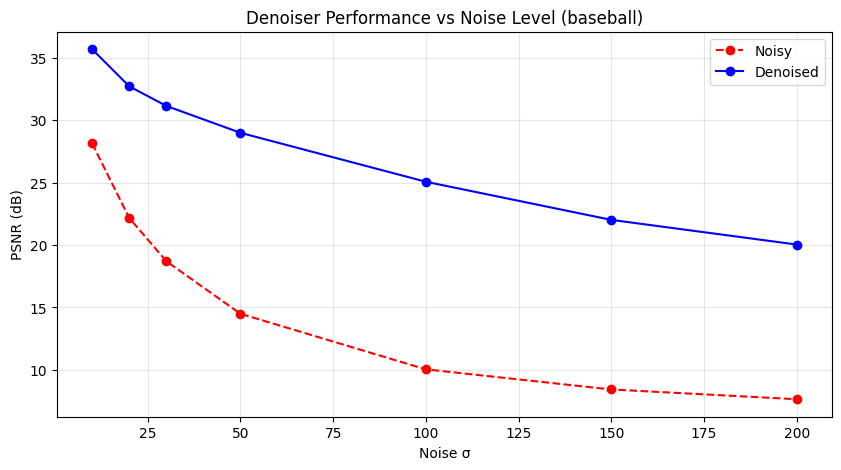

In [8]:
# Cell 9: Compare performance across noise levels
print(f"\n{'='*60}")
print(f"Performance across noise levels")
print(f"{'='*60}\n")

noise_levels = [10, 20, 30, 50, 100, 150, 200]
test_video_path = os.path.join(davis_root, videos[0])  # Use first video

noise_results = []
for sigma in noise_levels:
    clean, noisy, denoised, _ = tester.denoise_noisy_video(
        test_video_path, noise_std=sigma, resize_to=process_res, seed=42
    )
    m = tester.compute_metrics(noisy, clean, denoised)
    noise_results.append((sigma, m))
    print(f"  σ={sigma:3d}: Noisy {m['noisy_psnr_mean']:.1f} dB → Denoised {m['denoised_psnr_mean']:.1f} dB "
          f"(+{m['psnr_improvement']:.1f}), SSIM {m['denoised_ssim_mean']:.4f}")

# Plot
sigmas = [r[0] for r in noise_results]
psnrs = [r[1]['denoised_psnr_mean'] for r in noise_results]
noisy_psnrs = [r[1]['noisy_psnr_mean'] for r in noise_results]

plt.figure(figsize=(10, 5))
plt.plot(sigmas, noisy_psnrs, 'r--o', label='Noisy')
plt.plot(sigmas, psnrs, 'b-o', label='Denoised')
plt.xlabel('Noise σ')
plt.ylabel('PSNR (dB)')
plt.title(f'Denoiser Performance vs Noise Level ({videos[0]})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()